In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Site2data.csv')


In [3]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,9/1/2022 0:00,169.37,467047.31,2.626667
1,9/2/2022 0:00,185.25,500334.25,1.733333
2,9/3/2022 0:00,176.34,490534.07,2.343333
3,9/4/2022 0:00,165.04,458040.65,2.800000
4,9/5/2022 0:00,169.75,453424.37,2.530000
...,...,...,...,...
361,8/28/2023 0:00,256.67,885757.79,10.800000
362,8/29/2023 0:00,249.16,882327.23,11.790833
363,8/30/2023 0:00,250.94,916696.52,11.012500
364,8/31/2023 0:00,256.63,905968.97,11.706667


Training with units=50, dropout_rate=0.2, batch_size=32, epochs=50, optimizer=adam
Epoch 1/50
4/4 [==============================] - 10s 866ms/step - loss: 0.3449 - val_loss: 0.3331 - lr: 0.0010
Epoch 2/50
4/4 [==============================] - 0s 21ms/step - loss: 0.3262 - val_loss: 0.3133 - lr: 0.0010
Epoch 3/50
4/4 [==============================] - 0s 19ms/step - loss: 0.3075 - val_loss: 0.2934 - lr: 0.0010
Epoch 4/50
4/4 [==============================] - 0s 21ms/step - loss: 0.2887 - val_loss: 0.2733 - lr: 0.0010
Epoch 5/50
4/4 [==============================] - 0s 21ms/step - loss: 0.2708 - val_loss: 0.2526 - lr: 0.0010
Epoch 6/50
4/4 [==============================] - 0s 21ms/step - loss: 0.2496 - val_loss: 0.2312 - lr: 0.0010
Epoch 7/50
4/4 [==============================] - 0s 22ms/step - loss: 0.2301 - val_loss: 0.2092 - lr: 0.0010
Epoch 8/50
4/4 [==============================] - 0s 26ms/step - loss: 0.2095 - val_loss: 0.1860 - lr: 0.0010
Epoch 9/50
4/4 [===================

4/4 [==============================] - 0s 17ms/step - loss: 0.2206 - val_loss: 0.1973 - lr: 0.0010
Epoch 9/100
4/4 [==============================] - 0s 16ms/step - loss: 0.1996 - val_loss: 0.1735 - lr: 0.0010
Epoch 10/100
4/4 [==============================] - 0s 15ms/step - loss: 0.1767 - val_loss: 0.1492 - lr: 0.0010
Epoch 11/100
4/4 [==============================] - 0s 17ms/step - loss: 0.1543 - val_loss: 0.1251 - lr: 0.0010
Epoch 12/100
4/4 [==============================] - 0s 17ms/step - loss: 0.1314 - val_loss: 0.1019 - lr: 0.0010
Epoch 13/100
4/4 [==============================] - 0s 15ms/step - loss: 0.1109 - val_loss: 0.0796 - lr: 0.0010
Epoch 14/100
4/4 [==============================] - 0s 16ms/step - loss: 0.0911 - val_loss: 0.0599 - lr: 0.0010
Epoch 15/100
4/4 [==============================] - 0s 14ms/step - loss: 0.0722 - val_loss: 0.0442 - lr: 0.0010
Epoch 16/100
4/4 [==============================] - 0s 33ms/step - loss: 0.0620 - val_loss: 0.0333 - lr: 0.0010
Epoch 

4/4 [==============================] - 0s 24ms/step - loss: 0.0509 - val_loss: 0.0269 - lr: 0.0010
Epoch 20/150
4/4 [==============================] - 0s 32ms/step - loss: 0.0505 - val_loss: 0.0281 - lr: 0.0010
Epoch 21/150
4/4 [==============================] - 0s 29ms/step - loss: 0.0525 - val_loss: 0.0285 - lr: 0.0010
Epoch 22/150
4/4 [==============================] - 0s 39ms/step - loss: 0.0519 - val_loss: 0.0281 - lr: 0.0010
Epoch 23/150
4/4 [==============================] - 0s 22ms/step - loss: 0.0516 - val_loss: 0.0274 - lr: 0.0010
Epoch 24/150
4/4 [==============================] - 0s 31ms/step - loss: 0.0511 - val_loss: 0.0270 - lr: 0.0010
Epoch 25/150
4/4 [==============================] - 0s 34ms/step - loss: 0.0500 - val_loss: 0.0271 - lr: 0.0010
Epoch 26/150
4/4 [==============================] - 0s 45ms/step - loss: 0.0490 - val_loss: 0.0276 - lr: 0.0010
Epoch 27/150
4/4 [==============================] - 0s 35ms/step - loss: 0.0481 - val_loss: 0.0278 - lr: 0.0010
Epoch

Epoch 14/50
2/2 [==============================] - 0s 75ms/step - loss: 0.2292 - val_loss: 0.2136 - lr: 0.0010
Epoch 15/50
2/2 [==============================] - 0s 104ms/step - loss: 0.2171 - val_loss: 0.2017 - lr: 0.0010
Epoch 16/50
2/2 [==============================] - 0s 101ms/step - loss: 0.2072 - val_loss: 0.1896 - lr: 0.0010
Epoch 17/50
2/2 [==============================] - 0s 83ms/step - loss: 0.1949 - val_loss: 0.1774 - lr: 0.0010
Epoch 18/50
2/2 [==============================] - 0s 110ms/step - loss: 0.1850 - val_loss: 0.1650 - lr: 0.0010
Epoch 19/50
2/2 [==============================] - 0s 93ms/step - loss: 0.1722 - val_loss: 0.1525 - lr: 0.0010
Epoch 20/50
2/2 [==============================] - 0s 90ms/step - loss: 0.1611 - val_loss: 0.1400 - lr: 0.0010
Epoch 21/50
2/2 [==============================] - 0s 54ms/step - loss: 0.1484 - val_loss: 0.1275 - lr: 0.0010
Epoch 22/50
2/2 [==============================] - 0s 88ms/step - loss: 0.1380 - val_loss: 0.1152 - lr: 0.001

2/2 [==============================] - 0s 110ms/step - loss: 0.0503 - val_loss: 0.0270 - lr: 0.0010
Epoch 42/50
2/2 [==============================] - 0s 99ms/step - loss: 0.0489 - val_loss: 0.0269 - lr: 0.0010
Epoch 43/50
2/2 [==============================] - 0s 60ms/step - loss: 0.0496 - val_loss: 0.0269 - lr: 0.0010
Epoch 44/50
2/2 [==============================] - 0s 68ms/step - loss: 0.0489 - val_loss: 0.0270 - lr: 0.0010
Epoch 45/50
2/2 [==============================] - 0s 65ms/step - loss: 0.0483 - val_loss: 0.0269 - lr: 0.0010
Epoch 46/50
2/2 [==============================] - 0s 82ms/step - loss: 0.0493 - val_loss: 0.0271 - lr: 0.0010
Epoch 47/50
2/2 [==============================] - 0s 61ms/step - loss: 0.0488 - val_loss: 0.0272 - lr: 0.0010
Epoch 48/50
2/2 [==============================] - 0s 104ms/step - loss: 0.0503 - val_loss: 0.0271 - lr: 0.0010
Epoch 49/50
1/1 [==============================] - 2s 2s/step
MSE (normalized): 0.017840512627351472
Training with units=5

...

4/4 [==============================] - 0s 17ms/step - loss: 0.0489 - val_loss: 0.0277 - lr: 0.0010
Epoch 13/50
4/4 [==============================] - 0s 17ms/step - loss: 0.0505 - val_loss: 0.0273 - lr: 0.0010
Epoch 14/50
4/4 [==============================] - 0s 18ms/step - loss: 0.0511 - val_loss: 0.0270 - lr: 0.0010
Epoch 15/50
4/4 [==============================] - 0s 17ms/step - loss: 0.0490 - val_loss: 0.0269 - lr: 0.0010
Epoch 16/50
4/4 [==============================] - 0s 17ms/step - loss: 0.0497 - val_loss: 0.0271 - lr: 0.0010
Epoch 17/50
4/4 [==============================] - 0s 20ms/step - loss: 0.0465 - val_loss: 0.0274 - lr: 0.0010
Epoch 18/50
4/4 [==============================] - 0s 16ms/step - loss: 0.0476 - val_loss: 0.0282 - lr: 0.0010
Epoch 19/50
4/4 [==============================] - 0s 19ms/step - loss: 0.0481 - val_loss: 0.0295 - lr: 0.0010
Epoch 20/50
4/4 [==============================] - 0s 17ms/step - loss: 0.0499 - val_loss: 0.0283 - lr: 0.0010
Epoch 21/50
4

Epoch 11/150
4/4 [==============================] - 0s 17ms/step - loss: 0.0511 - val_loss: 0.0337 - lr: 0.0010
Epoch 12/150
4/4 [==============================] - 0s 27ms/step - loss: 0.0549 - val_loss: 0.0342 - lr: 0.0010
Epoch 13/150
4/4 [==============================] - 0s 22ms/step - loss: 0.0520 - val_loss: 0.0312 - lr: 0.0010
Epoch 14/150
4/4 [==============================] - 0s 21ms/step - loss: 0.0506 - val_loss: 0.0285 - lr: 0.0010
Epoch 15/150
4/4 [==============================] - 0s 22ms/step - loss: 0.0473 - val_loss: 0.0279 - lr: 0.0010
Epoch 16/150
4/4 [==============================] - 0s 21ms/step - loss: 0.0485 - val_loss: 0.0286 - lr: 0.0010
Epoch 17/150
4/4 [==============================] - 0s 20ms/step - loss: 0.0476 - val_loss: 0.0293 - lr: 0.0010
Epoch 18/150
4/4 [==============================] - 0s 18ms/step - loss: 0.0469 - val_loss: 0.0295 - lr: 0.0010
Epoch 19/150
4/4 [==============================] - 0s 22ms/step - loss: 0.0471 - val_loss: 0.0289 - lr:

2/2 [==============================] - 0s 40ms/step - loss: 0.0462 - val_loss: 0.0301 - lr: 0.0010
Epoch 34/50
2/2 [==============================] - 0s 45ms/step - loss: 0.0464 - val_loss: 0.0298 - lr: 0.0010
Epoch 35/50
2/2 [==============================] - 0s 38ms/step - loss: 0.0471 - val_loss: 0.0294 - lr: 0.0010
Epoch 36/50
2/2 [==============================] - 0s 37ms/step - loss: 0.0464 - val_loss: 0.0289 - lr: 0.0010
Epoch 37/50
1/1 [==============================] - 1s 1s/step
MSE (normalized): 0.01680167023903931
Training with units=150, dropout_rate=0.4, batch_size=64, epochs=50, optimizer=rmsprop
Epoch 1/50
2/2 [==============================] - 11s 2s/step - loss: 0.3491 - val_loss: 0.3242 - lr: 0.0010
Epoch 2/50
2/2 [==============================] - 0s 47ms/step - loss: 0.3181 - val_loss: 0.2978 - lr: 0.0010
Epoch 3/50
2/2 [==============================] - 0s 39ms/step - loss: 0.2942 - val_loss: 0.2747 - lr: 0.0010
Epoch 4/50
2/2 [==============================] - 0s

2/2 [==============================] - 11s 2s/step - loss: 0.3470 - val_loss: 0.3185 - lr: 0.0010
Epoch 2/100
2/2 [==============================] - 0s 38ms/step - loss: 0.3122 - val_loss: 0.2888 - lr: 0.0010
Epoch 3/100
2/2 [==============================] - 0s 35ms/step - loss: 0.2850 - val_loss: 0.2619 - lr: 0.0010
Epoch 4/100
2/2 [==============================] - 0s 36ms/step - loss: 0.2602 - val_loss: 0.2361 - lr: 0.0010
Epoch 5/100
2/2 [==============================] - 0s 40ms/step - loss: 0.2357 - val_loss: 0.2105 - lr: 0.0010
Epoch 6/100
2/2 [==============================] - 0s 35ms/step - loss: 0.2125 - val_loss: 0.1861 - lr: 0.0010
Epoch 7/100
2/2 [==============================] - 0s 38ms/step - loss: 0.1897 - val_loss: 0.1618 - lr: 0.0010
Epoch 8/100
2/2 [==============================] - 0s 42ms/step - loss: 0.1691 - val_loss: 0.1393 - lr: 0.0010
Epoch 9/100
2/2 [==============================] - 0s 33ms/step - loss: 0.1457 - val_loss: 0.1182 - lr: 0.0010
Epoch 10/100
2

2/2 [==============================] - 8s 2s/step - loss: 0.3456 - val_loss: 0.3153 - lr: 0.0010
Epoch 2/150
2/2 [==============================] - 0s 37ms/step - loss: 0.3095 - val_loss: 0.2851 - lr: 0.0010
Epoch 3/150
2/2 [==============================] - 0s 38ms/step - loss: 0.2820 - val_loss: 0.2572 - lr: 0.0010
Epoch 4/150
2/2 [==============================] - 0s 50ms/step - loss: 0.2554 - val_loss: 0.2309 - lr: 0.0010
Epoch 5/150
2/2 [==============================] - 0s 45ms/step - loss: 0.2323 - val_loss: 0.2049 - lr: 0.0010
Epoch 6/150
2/2 [==============================] - 0s 47ms/step - loss: 0.2065 - val_loss: 0.1795 - lr: 0.0010
Epoch 7/150
2/2 [==============================] - 0s 47ms/step - loss: 0.1839 - val_loss: 0.1555 - lr: 0.0010
Epoch 8/150
2/2 [==============================] - 0s 44ms/step - loss: 0.1591 - val_loss: 0.1322 - lr: 0.0010
Epoch 9/150
2/2 [==============================] - 0s 44ms/step - loss: 0.1400 - val_loss: 0.1108 - lr: 0.0010
Epoch 10/150
2/

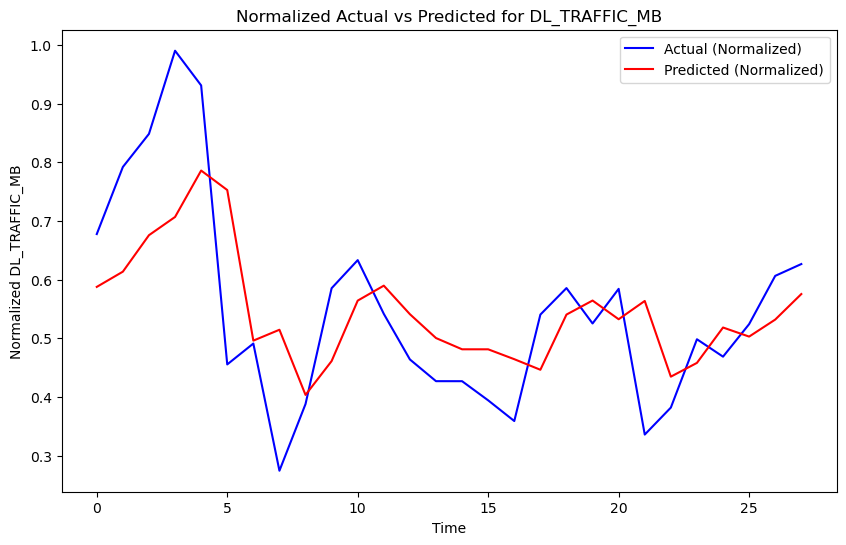

In [2]:

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'AVG_NO_USER' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=1)
X_train, y_train = create_dataset(train, look_back=1)
X_test, y_test = create_dataset(test, look_back=1)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Manual hyperparameter tuning loop
best_mse = float('inf')
best_params = {}
best_model = None
best_history = None

# Loop through different hyperparameter configurations
for units in [50, 100, 150]:
    for dropout_rate in [0.2, 0.3, 0.4]:
        for batch_size in [32, 64]:
            for epochs in [50, 100, 150]:
                for optimizer in ['adam', 'rmsprop']:
                    print(f'Training with units={units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}')
                    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
                    
                    # Calculate MSE with normalized data
                    mse = mean_squared_error(y_test, test_predict)
                    print(f'MSE (normalized): {mse}')
                    
                    # Track the best model
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'units': units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}
                        best_model = model
                        best_history = history

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Plot the best model's predictions with normalized values
best_test_predict = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()